In [1]:
import pandas as pd



In [1]:
import pandas as pd

# Load the datasets
brands = pd.read_csv(r"C:\Users\honor\Documents\nike_addidas_case\brands.csv")
finance = pd.read_csv(r"C:\Users\honor\Documents\nike_addidas_case\finance.csv")

# Merge on product_id
merged_df = pd.merge(brands, finance, on="product_id", how="inner")

# Save result
merged_df.to_csv(r"C:\Users\honor\Documents\nike_addidas_case\data\merged_products.csv", index=False)

# Preview
print(merged_df.head())

  product_id   brand  listing_price  sale_price  discount  revenue
0     AH2430     NaN            NaN         NaN       NaN      NaN
1     G27341  Adidas          75.99       37.99       0.5  1641.17
2     CM0081  Adidas           9.99        5.99       0.4   398.93
3     B44832  Adidas          69.99       34.99       0.5  2204.37
4     D98205  Adidas          79.99       39.99       0.5  5182.70


In [2]:
import pandas as pd

# --- BASIC COUNTS ---
print("Brands rows:", len(brands))
print("Finance rows:", len(finance))
print("Merged rows:", len(merged_df))
print()

# --- CHECK UNIQUE KEYS ---
print("Unique product_id in brands:", brands["product_id"].nunique())
print("Unique product_id in finance:", finance["product_id"].nunique())
print("Unique product_id in merged:", merged_df["product_id"].nunique())
print()

# --- CHECK FOR DUPLICATES ---
dup_brands = brands["product_id"].duplicated().sum()
dup_finance = finance["product_id"].duplicated().sum()
dup_merged = merged_df["product_id"].duplicated().sum()

print("Duplicate product_id in brands:", dup_brands)
print("Duplicate product_id in finance:", dup_finance)
print("Duplicate product_id in merged:", dup_merged)
print()

# --- CHECK FOR LOST ROWS ---
brands_not_merged = brands[~brands["product_id"].isin(merged_df["product_id"])]
finance_not_merged = finance[~finance["product_id"].isin(merged_df["product_id"])]

print("Brands rows not merged:", len(brands_not_merged))
print("Finance rows not merged:", len(finance_not_merged))
print()

# --- NULL CHECK ---
print("Null values in merged:")
print(merged_df.isnull().sum())
print()

# --- RANDOM SPOT CHECK ---
print("Random sample of merged data:")
print(merged_df.sample(5))

Brands rows: 3179
Finance rows: 3179
Merged rows: 3179

Unique product_id in brands: 3179
Unique product_id in finance: 3179
Unique product_id in merged: 3179

Duplicate product_id in brands: 0
Duplicate product_id in finance: 0
Duplicate product_id in merged: 0

Brands rows not merged: 0
Finance rows not merged: 0

Null values in merged:
product_id        0
brand            59
listing_price    59
sale_price       59
discount         59
revenue          59
dtype: int64

Random sample of merged data:
      product_id   brand  listing_price  sale_price  discount  revenue
1352      FV2806  Adidas          79.99       79.99       0.0  6047.24
1515      EE6329  Adidas          79.99       47.99       0.4  3800.81
718       EE8115  Adidas          59.99       35.99       0.4   777.38
2661  CD0888-002    Nike           0.00       75.95       0.0   410.13
2589      CM6027  Adidas          39.99       39.99       0.0  1079.73


In [3]:
merged_df = pd.merge(
    brands,
    finance,
    on="product_id",
    how="inner",
    indicator=True
)

print(merged_df["_merge"].value_counts())

_merge
both          3179
left_only        0
right_only       0
Name: count, dtype: int64


In [4]:
import pandas as pd

# Load files
products = pd.read_csv(r"C:\Users\honor\Documents\nike_addidas_case\info.csv")
merged_products = pd.read_csv(r"C:\Users\honor\Documents\nike_addidas_case\data\merged_products.csv")

# Standardize column names
products.columns = products.columns.str.lower().str.strip()
merged_products.columns = merged_products.columns.str.lower().str.strip()

# Merge on product_id
final_merged = pd.merge(
    merged_products,
    products,
    on="product_id",
    how="left"
)

# Save result
final_merged.to_csv("final_merged_products.csv", index=False)

# Verification checks
print("Products rows:", len(products))
print("Merged_products rows:", len(merged_products))
print("Final merged rows:", len(final_merged))
print("Unmatched product_ids (missing product_name):", final_merged["product_name"].isna().sum())

Products rows: 3179
Merged_products rows: 3179
Final merged rows: 3179
Unmatched product_ids (missing product_name): 59


In [6]:
import pandas as pd

# Load datasets
reviews = pd.read_csv(r"C:\Users\honor\Documents\nike_addidas_case\reviews.csv")
products = pd.read_csv(r"data\final_merged_products.csv")

# Merge on product_id (adjust if your key column differs)
merged = pd.merge(reviews, products, on="product_id", how="left")

# Save result
merged.to_csv("merged_reviews_products.csv", index=False)

print("Merge complete. Output saved as merged_reviews_products.csv")
print("Merged shape:", merged.shape)


Merge complete. Output saved as merged_reviews_products.csv
Merged shape: (3179, 10)


In [9]:
import pandas as pd

# Load merged file
merged = pd.read_csv("data/merged_reviews_products.csv")

# 1. Check row count consistency
reviews = pd.read_csv("data/reviews.csv")
print("Review rows:", len(reviews))
print("Merged rows:", len(merged))

# 2. Check unmatched product_ids (left merge expectation)
unmatched = merged["product_id"].isna().sum()
print("Unmatched product_id rows:", unmatched)

# 3. Verify merge coverage
coverage = merged["product_id"].notna().mean()
print(f"Merge coverage: {coverage:.2%}")

# 4. Check duplicate keys after merge
dup_keys = merged["product_id"].duplicated().sum()
print("Duplicate product_id rows:", dup_keys)

# 5. Inspect random sample
print(merged.sample(5))


Review rows: 3179
Merged rows: 3179
Unmatched product_id rows: 0
Merge coverage: 100.00%
Duplicate product_id rows: 0
      product_id  rating  reviews   brand  listing_price  sale_price  \
2875  CD4373-001     4.7      3.0    Nike           0.00      109.95   
1024      EE7740     4.8     38.0  Adidas         129.99       77.99   
2681  CQ6569-001     0.0      0.0    Nike         159.95      111.97   
397       CM0074     4.2     22.0  Adidas           9.99        5.99   
1333      EE8138     3.0     15.0  Adidas          49.99       49.99   

      discount  revenue                                      product_name  \
2875       0.0   593.73                                 Nike React Vision   
1024       0.4  5334.52           Men's adidas Originals Temper Run Shoes   
2681       0.0     0.00                          Nike Air Max Tailwind 99   
397        0.4   237.20                 Women's adidas Swim Jung Slippers   
1333       0.0  1349.73  Men's adidas Sport Inspired Lite Racer 

In [11]:
df = pd.read_csv(r"data/merged_reviews_products.csv")

In [12]:
print(df.head(5))

  product_id  rating  reviews   brand  listing_price  sale_price  discount  \
0     AH2430     NaN      NaN     NaN            NaN         NaN       NaN   
1     G27341     3.3     24.0  Adidas          75.99       37.99       0.5   
2     CM0081     2.6     37.0  Adidas           9.99        5.99       0.4   
3     B44832     4.1     35.0  Adidas          69.99       34.99       0.5   
4     D98205     3.5     72.0  Adidas          79.99       39.99       0.5   

   revenue                                      product_name  \
0      NaN                                               NaN   
1  1641.17              Women's adidas Originals Sleek Shoes   
2   398.93                 Women's adidas Swim Puka Slippers   
3  2204.37  Women's adidas Sport Inspired Questar Ride Shoes   
4  5182.70          Women's adidas Originals Taekwondo Shoes   

                                         description  
0                                                NaN  
1  A modern take on adidas sport her

In [13]:
df.describe()

,rating,reviews,listing_price,sale_price,discount,revenue
count,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000
mean,3.265801,41.545513,69.719455,60.103035,0.276090,3951.571263
std,1.392685,31.361668,46.586909,41.906852,0.224955,4440.312551
min,0.000000,0.000000,0.000000,4.490000,0.000000,0.000000
25%,2.600000,12.000000,45.990000,29.990000,0.000000,863.890000
50%,3.500000,39.000000,59.990000,45.990000,0.400000,2735.280000
75%,4.400000,69.000000,89.990000,77.990000,0.500000,5345.015000
max,5.000000,223.000000,299.990000,365.000000,0.600000,64203.930000


In [14]:
#Todo: drop nulls
df.dropna(inplace=True)

<Axes: title={'center': 'Missing Values by Column'}>

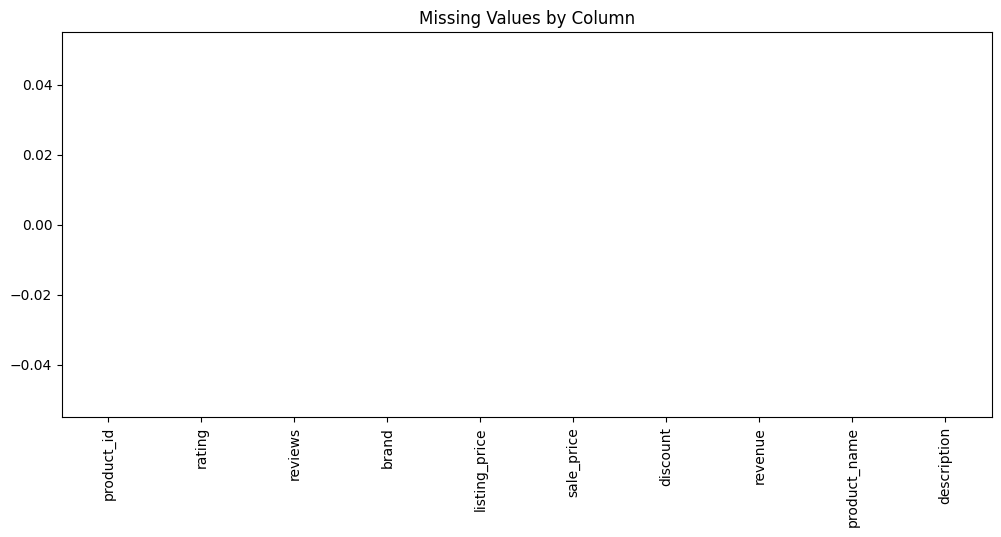

In [17]:
(df.isnull().sum()
   .sort_values(ascending=False)
   .plot(kind='bar', figsize=(12,5), title="Missing Values by Column"))


In [20]:
print(df.columns)


# import pandas as pd

# # assume price column is named 'price'

# df["price_label"] = pd.qcut(
#     df["price"],
#     q=4,
#     labels=["Budget", "Average", "Expensive", "Elite"]
# )


Index(['product_id', 'rating', 'reviews', 'brand', 'listing_price',
       'sale_price', 'discount', 'revenue', 'product_name', 'description'],
      dtype='object')


In [21]:
print(df.head())

  product_id  rating  reviews   brand  listing_price  sale_price  discount  \
1     G27341     3.3     24.0  Adidas          75.99       37.99       0.5   
2     CM0081     2.6     37.0  Adidas           9.99        5.99       0.4   
3     B44832     4.1     35.0  Adidas          69.99       34.99       0.5   
4     D98205     3.5     72.0  Adidas          79.99       39.99       0.5   
5     B75586     1.0     45.0  Adidas          47.99       19.20       0.6   

   revenue                                       product_name  \
1  1641.17               Women's adidas Originals Sleek Shoes   
2   398.93                  Women's adidas Swim Puka Slippers   
3  2204.37   Women's adidas Sport Inspired Questar Ride Shoes   
4  5182.70           Women's adidas Originals Taekwondo Shoes   
5  1555.20  Women's adidas Sport Inspired Duramo Lite 2.0 ...   

                                         description  
1  A modern take on adidas sport heritage, tailor...  
2  These adidas Puka slippers 

In [23]:
brands = ["Adidas", "Nike"]
df_brand = df[df["brand"].isin(brands)].copy()

df_brand["price_tier"] = pd.qcut(
    df_brand["listing_price"],
    q=4,
    labels=["Budget", "Average", "Expensive", "Elite"]
)



In [25]:
summary = (
    df_brand
    .groupby(["brand", "price_tier"])
    .agg(
        product_volume=("product_id", "count"),
        avg_revenue=("revenue", "mean")
    )
    .reset_index()
)

summary = summary.sort_values(["brand", "price_tier"])

print(summary)


    brand price_tier  product_volume  avg_revenue
0  Adidas     Budget             574  2015.676341
1  Adidas    Average             655  3035.303588
2  Adidas  Expensive             759  4621.557747
3  Adidas      Elite             587  8302.784804
4    Nike     Budget             357  1596.328207
5    Nike    Average               8   675.592500
6    Nike  Expensive              47   500.562766
7    Nike      Elite             130  1367.448154


C:\Users\honor\AppData\Local\Temp\ipykernel_20888\2135275983.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["brand", "price_tier"])


In [26]:
pivot = summary.pivot(
    index="price_tier",
    columns="brand",
    values=["product_volume", "avg_revenue"]
)

print(pivot)


           product_volume         avg_revenue             
brand              Adidas   Nike       Adidas         Nike
price_tier                                                
Budget              574.0  357.0  2015.676341  1596.328207
Average             655.0    8.0  3035.303588   675.592500
Expensive           759.0   47.0  4621.557747   500.562766
Elite               587.0  130.0  8302.784804  1367.448154


In [27]:
# create final dataframe
adidas_vs_nike = (
    df_brand
    .groupby(["brand", "price_tier"])
    .agg(
        num_products=("product_id", "count"),
        mean_revenue=("revenue", "mean")
    )
    .reset_index()
    .rename(columns={"price_tier": "price_label"})
)

# round numeric values
adidas_vs_nike["num_products"] = adidas_vs_nike["num_products"].round(2)
adidas_vs_nike["mean_revenue"] = adidas_vs_nike["mean_revenue"].round(2)

print(adidas_vs_nike)


    brand price_label  num_products  mean_revenue
0  Adidas      Budget           574       2015.68
1  Adidas     Average           655       3035.30
2  Adidas   Expensive           759       4621.56
3  Adidas       Elite           587       8302.78
4    Nike      Budget           357       1596.33
5    Nike     Average             8        675.59
6    Nike   Expensive            47        500.56
7    Nike       Elite           130       1367.45


C:\Users\honor\AppData\Local\Temp\ipykernel_20888\4038030387.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["brand", "price_tier"])


In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df[df['brand'].isin(['Nike','Adidas'])].boxplot(
    column='revenue',
    by=['brand','revenue_quartile']
)

plt.title("Revenue Distribution by Quartile: Nike vs Adidas")
plt.suptitle("")
plt.xlabel("Brand and Revenue Quartile")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


KeyError: 'revenue_quartile'

<Figure size 1000x600 with 0 Axes>

In [28]:
import pandas as pd
import numpy as np

# create description length column (character count)
df['description_length'] = df['description'].astype(str).str.len()

# create bins of 100-character intervals
max_len = df['description_length'].max()
bins = np.arange(0, max_len + 100, 100)

df['length_bin'] = pd.cut(df['description_length'], bins=bins)

# aggregate metrics
description_lengths = (
    df.groupby('length_bin')
      .agg(
          description_length=('description_length', 'mean'),
          mean_rating=('rating', 'mean'),
          total_reviews=('reviews', 'sum')
      )
      .reset_index(drop=True)
      .round(2)
)

description_lengths


C:\Users\honor\AppData\Local\Temp\ipykernel_20888\3017457846.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('length_bin')


,description_length,mean_rating,total_reviews
0,83.57,2.26,36.0
1,174.11,3.19,17719.0
2,249.97,3.28,76115.0
3,338.39,3.29,28994.0
4,432.92,3.35,4984.0
5,552.27,3.12,852.0
6,647.00,3.65,818.0


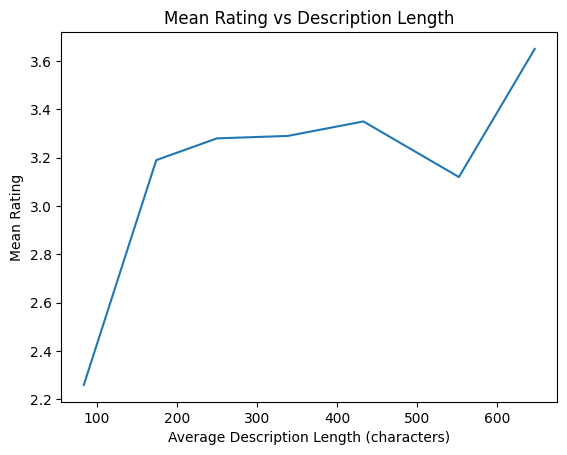

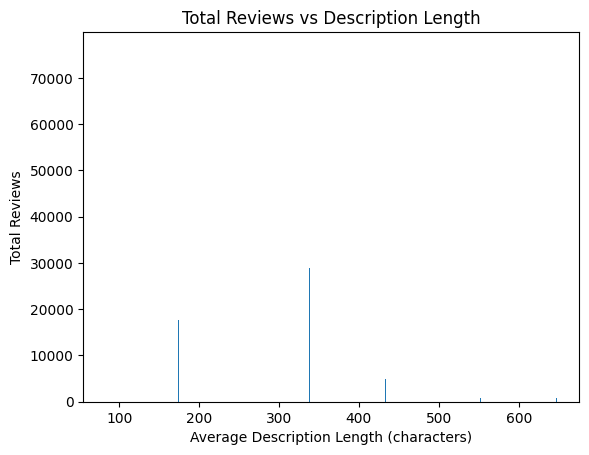

In [29]:
import matplotlib.pyplot as plt

# Mean rating vs description length
plt.figure()
plt.plot(description_lengths['description_length'], description_lengths['mean_rating'])
plt.title('Mean Rating vs Description Length')
plt.xlabel('Average Description Length (characters)')
plt.ylabel('Mean Rating')
plt.show()

# Total reviews vs description length
plt.figure()
plt.bar(description_lengths['description_length'], description_lengths['total_reviews'])
plt.title('Total Reviews vs Description Length')
plt.xlabel('Average Description Length (characters)')
plt.ylabel('Total Reviews')
plt.show()


<Figure size 1000x600 with 0 Axes>

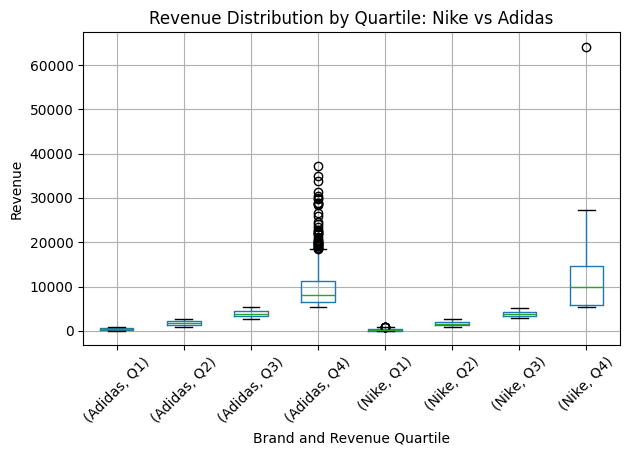

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Create revenue quartiles
df['revenue_quartile'] = pd.qcut(df['revenue'], 4, labels=['Q1','Q2','Q3','Q4'])

# Filter Nike vs Adidas
subset = df[df['brand'].isin(['Nike','Adidas'])]

# Boxplot
plt.figure(figsize=(10,6))

subset.boxplot(
    column='revenue',
    by=['brand','revenue_quartile']
)

plt.title("Revenue Distribution by Quartile: Nike vs Adidas")
plt.suptitle("")
plt.xlabel("Brand and Revenue Quartile")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Decision Tree Regressor Performance
MAE: 862.91
RMSE: 2061.81
R^2: 0.8199

Feature Importances:
         feature  importance
3     sale_price    0.512838
1        reviews    0.487162
0         rating    0.000000
2  listing_price    0.000000
4       discount    0.000000


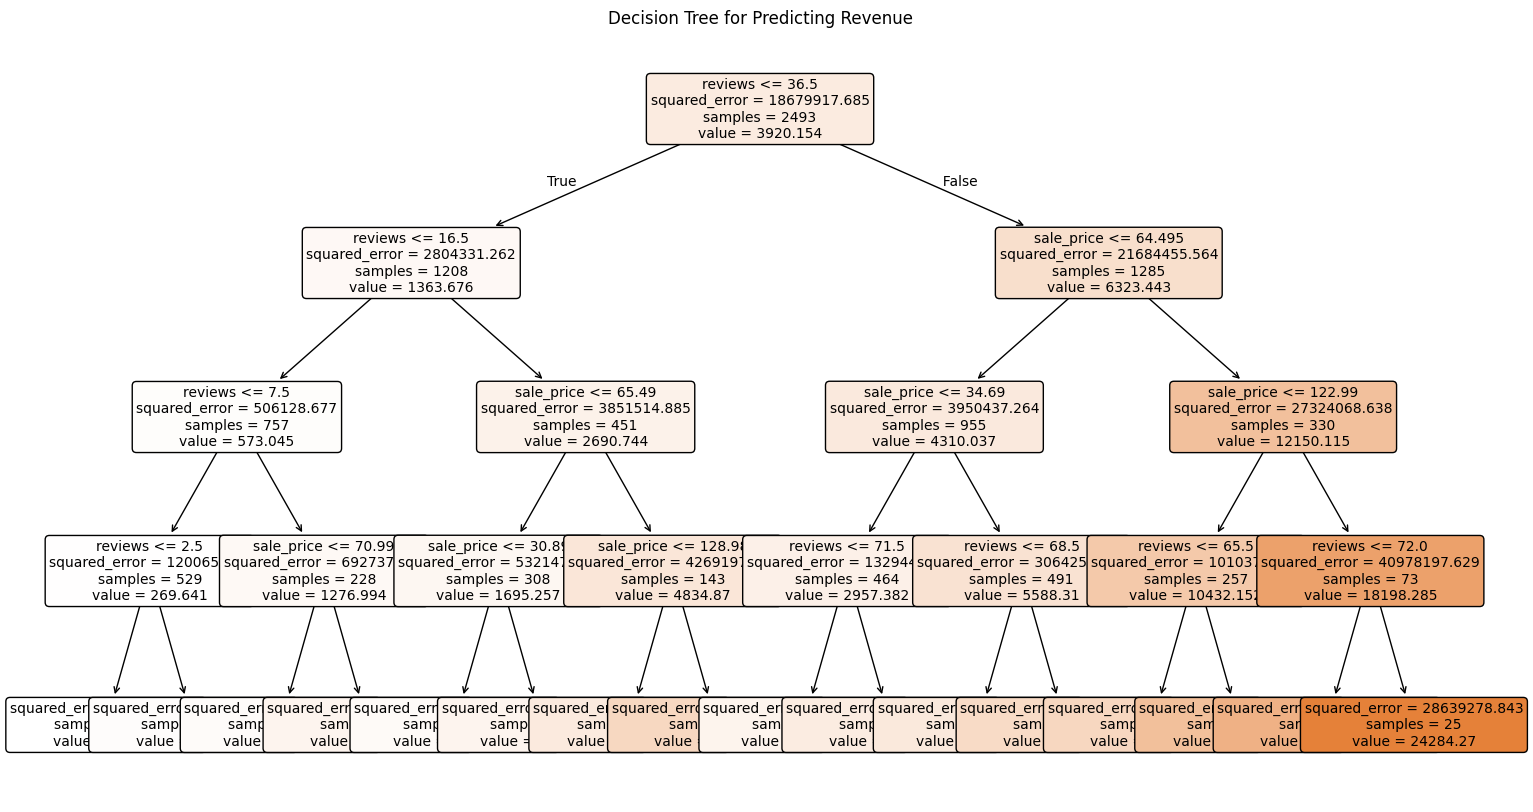

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Select features and target
features = ['rating', 'reviews', 'listing_price', 'sale_price', 'discount']
X = df[features].copy()
y = df['revenue'].copy()

# Drop rows with missing values in selected columns
model_df = pd.concat([X, y], axis=1).dropna()
X = model_df[features]
y = model_df['revenue']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train decision tree regressor
tree_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
tree_model.fit(X_train, y_train)

# Predictions
y_pred = tree_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Decision Tree Regressor Performance")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(importance_df)

# Plot the tree
plt.figure(figsize=(18,10))
plot_tree(
    tree_model,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Predicting Revenue")
plt.show()


Feature Importances:
         feature  importance
0     sale_price    0.512838
1        reviews    0.487162
2         rating    0.000000
3  listing_price    0.000000
4       discount    0.000000


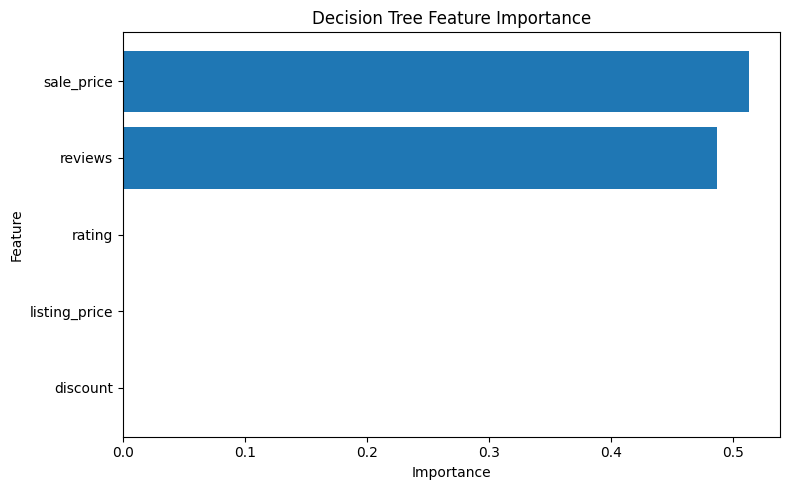

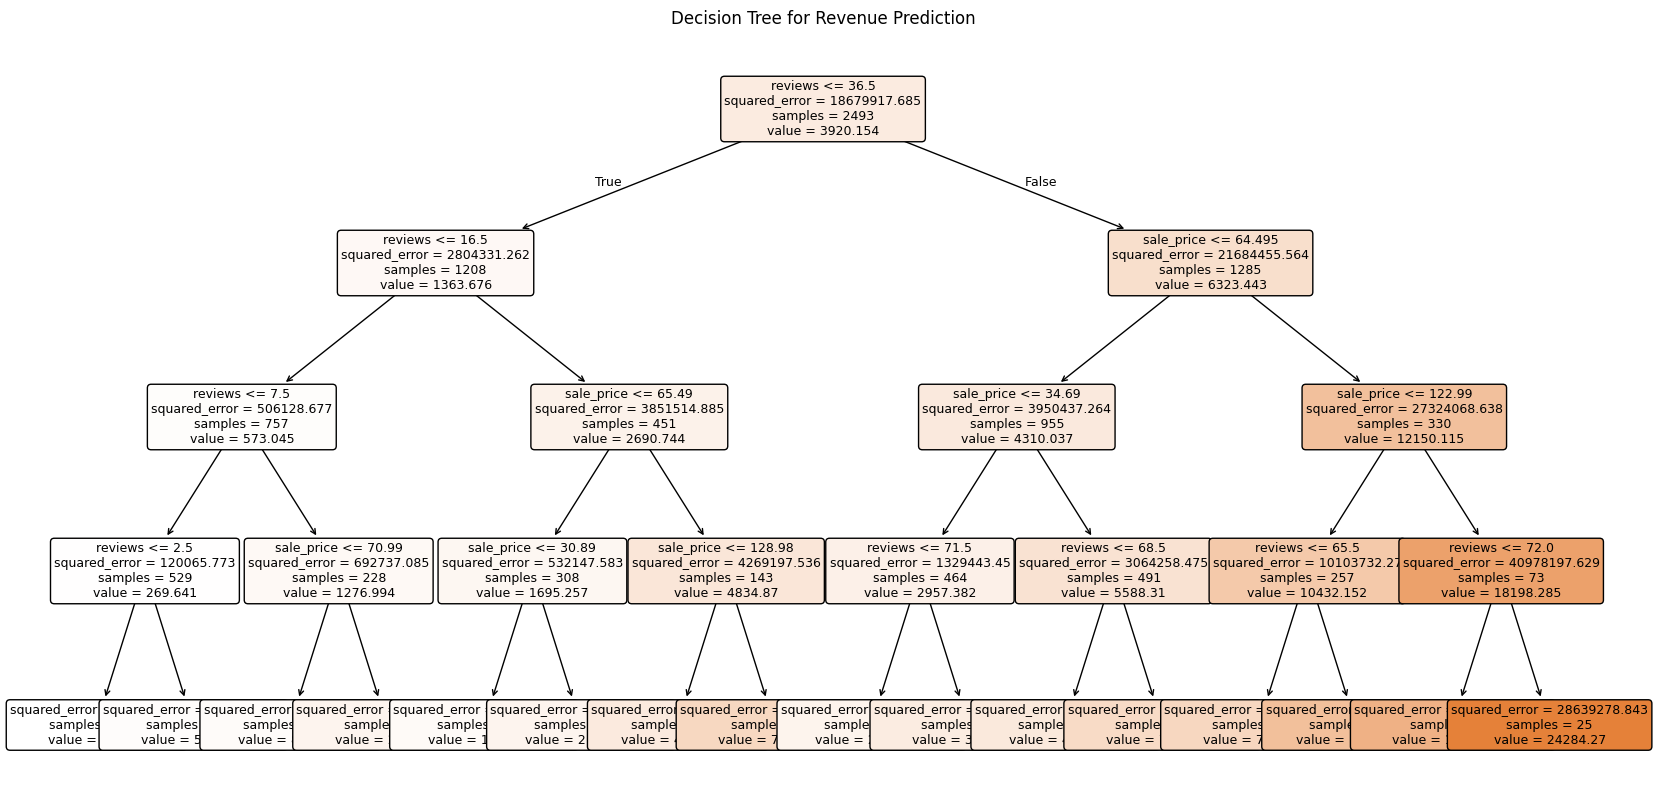


Decision Rules:

|--- reviews <= 36.50
|   |--- reviews <= 16.50
|   |   |--- reviews <= 7.50
|   |   |   |--- reviews <= 2.50
|   |   |   |   |--- value: [99.99]
|   |   |   |--- reviews >  2.50
|   |   |   |   |--- value: [579.91]
|   |   |--- reviews >  7.50
|   |   |   |--- sale_price <= 70.99
|   |   |   |   |--- value: [837.10]
|   |   |   |--- sale_price >  70.99
|   |   |   |   |--- value: [2174.37]
|   |--- reviews >  16.50
|   |   |--- sale_price <= 65.49
|   |   |   |--- sale_price <= 30.89
|   |   |   |   |--- value: [1064.82]
|   |   |   |--- sale_price >  30.89
|   |   |   |   |--- value: [2120.12]
|   |   |--- sale_price >  65.49
|   |   |   |--- sale_price <= 128.98
|   |   |   |   |--- value: [4080.80]
|   |   |   |--- sale_price >  128.98
|   |   |   |   |--- value: [7675.21]
|--- reviews >  36.50
|   |--- sale_price <= 64.49
|   |   |--- sale_price <= 34.69
|   |   |   |--- reviews <= 71.50
|   |   |   |   |--- value: [2267.37]
|   |   |   |--- reviews >  71.50
|   

In [35]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# 1) Feature importance table
# -----------------------------
importance_df = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': tree_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("Feature Importances:")
print(importance_df)

# -----------------------------
# 2) Feature importance chart
# -----------------------------
plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Full tree visualization
# -----------------------------
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree for Revenue Prediction")
plt.show()

# -----------------------------
# 4) Print tree as decision rules
# -----------------------------
rules_text = export_text(tree_model, feature_names=list(X_train.columns))
print("\nDecision Rules:\n")
print(rules_text)

# -----------------------------
# 5) Show decision path for one example
# -----------------------------
example_idx = 0   # change this to inspect another row from X_test
example = X_test.iloc[[example_idx]]
predicted_revenue = tree_model.predict(example)[0]

node_indicator = tree_model.decision_path(example)
leaf_id = tree_model.apply(example)

feature_names = list(X_train.columns)
tree_ = tree_model.tree_

print("\n" + "="*60)
print("Decision path for one example")
print("="*60)
print("Input values:")
print(example)

for node_id in node_indicator.indices:
    if node_id == leaf_id[0]:
        print(f"--> Reached leaf node {node_id}")
        continue
    
    feature_index = tree_.feature[node_id]
    threshold = tree_.threshold[node_id]
    feature_name = feature_names[feature_index]
    value = example.iloc[0, feature_index]
    
    if value <= threshold:
        decision = "<="
    else:
        decision = ">"
    
    print(
        f"Node {node_id}: {feature_name} = {value:.2f} "
        f"{decision} {threshold:.2f}"
    )

print(f"\nPredicted revenue for this example: {predicted_revenue:.2f}")

# -----------------------------
# 6) Compare actual vs predicted for that example
# -----------------------------
actual_revenue = y_test.iloc[example_idx]
print(f"Actual revenue for this example: {actual_revenue:.2f}")
print(f"Prediction error: {predicted_revenue - actual_revenue:.2f}")


In [ ]:
# Plain-English explanation for one prediction
example_idx = 0
example = X_test.iloc[[example_idx]]
predicted_revenue = tree_model.predict(example)[0]

node_indicator = tree_model.decision_path(example)
leaf_id = tree_model.apply(example)

feature_names = list(X_train.columns)
tree_ = tree_model.tree_

steps = []
for node_id in node_indicator.indices:
    if node_id == leaf_id[0]:
        continue
    
    feature_index = tree_.feature[node_id]
    threshold = tree_.threshold[node_id]
    feature_name = feature_names[feature_index]
    value = example.iloc[0, feature_index]
    
    if value <= threshold:
        steps.append(f"{feature_name} ({value:.2f}) was <= {threshold:.2f}")
    else:
        steps.append(f"{feature_name} ({value:.2f}) was > {threshold:.2f}")

print("Why this product got its predicted revenue:")
for i, step in enumerate(steps, start=1):
    print(f"{i}. {step}")
print(f"\nFinal predicted revenue: {predicted_revenue:.2f}")


Why this product got its predicted revenue:
1. reviews (6.00) was <= 36.50
2. reviews (6.00) was <= 16.50
3. reviews (6.00) was <= 7.50
4. reviews (6.00) was > 2.50

Final predicted revenue: 579.91


In [37]:
# Plain-English explanation for one prediction
example_idx = 1
example = X_test.iloc[[example_idx]]
predicted_revenue = tree_model.predict(example)[0]

node_indicator = tree_model.decision_path(example)
leaf_id = tree_model.apply(example)

feature_names = list(X_train.columns)
tree_ = tree_model.tree_

steps = []
for node_id in node_indicator.indices:
    if node_id == leaf_id[0]:
        continue
    
    feature_index = tree_.feature[node_id]
    threshold = tree_.threshold[node_id]
    feature_name = feature_names[feature_index]
    value = example.iloc[0, feature_index]
    
    if value <= threshold:
        steps.append(f"{feature_name} ({value:.2f}) was <= {threshold:.2f}")
    else:
        steps.append(f"{feature_name} ({value:.2f}) was > {threshold:.2f}")

print("Why this product got its predicted revenue:")
for i, step in enumerate(steps, start=1):
    print(f"{i}. {step}")
print(f"\nFinal predicted revenue: {predicted_revenue:.2f}")


Why this product got its predicted revenue:
1. reviews (52.00) was > 36.50
2. sale_price (29.99) was <= 64.49
3. sale_price (29.99) was <= 34.69
4. reviews (52.00) was <= 71.50

Final predicted revenue: 2267.37


In [ ]:
#TODO: is a random forest just a series of decison trees wherein the best performing tree is selected?
#TODO: contrast this interpretability with that of a neural network

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Features / target
X = df.drop(columns=["revenue"])
y = df["revenue"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
rf = RandomForestRegressor(
    n_estimators=300,        # number of trees
    max_depth=None,          # allow full growth
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

ValueError: could not convert string to float: 'EH3522'

In [ ]:
import pandas as pd

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(15))

In [ ]:
import matplotlib.pyplot as plt

feat_imp.head(15).plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.show()